# Task 2: Feature Engineering

Building customer-level features for the churn model: RFM, average order value, tenure, return behaviour, and a few engagement signals.


## Scope and snapshot convention

A quick note on what this notebook is doing before we dive in.

The input is the cleaned transaction file from Notebook 1 (`clean_transactions.csv`), and the output is one row per customer aggregated over their full history.

Recency and customer-age features need a "today" to measure against. Rather than picking one here, I reuse the observation date that Notebook 1 already recorded, so the two notebooks agree on what counts as the latest data point.

One thing worth flagging: these are descriptive features over the *whole* history, which is fine for profiling but would leak the future if used to predict churn directly. Notebook 3 handles that by recomputing a smaller set of features inside an earlier window and labelling churn from what happens after it. So the snapshot here and the one in Notebook 3 are different on purpose.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
sns.set_style('whitegrid')


In [ ]:
BASE_DIR = Path.cwd()
clean_file = BASE_DIR / 'clean_transactions.csv'

if clean_file.exists():
    df = pd.read_csv(clean_file, parse_dates=['invoice_date'])
else:
    # Fallback if Notebook 1 hasn't been run: read the raw file and clean the bare minimum.
    # The rename map handles both common column layouts: Invoice / Price / Customer ID
    # and InvoiceNo / UnitPrice / CustomerID.
    raw = pd.read_excel(BASE_DIR / 'Online retail dataset.xlsx')
    raw.columns = raw.columns.str.strip().str.lower().str.replace(' ', '_', regex=False)
    rename_map = {
        'invoice': 'invoice_no', 'invoiceno': 'invoice_no',
        'stockcode': 'stock_code',
        'invoicedate': 'invoice_date',
        'price': 'unit_price', 'unitprice': 'unit_price',
        'customerid': 'customer_id', 'customer_id': 'customer_id',
    }
    raw = raw.rename(columns={c: rename_map.get(c, c) for c in raw.columns})
    raw['invoice_date'] = pd.to_datetime(raw['invoice_date'], errors='coerce')
    df = raw.dropna(subset=['customer_id', 'invoice_date']).copy()

# Cast the id through a nullable int so float junk like "12346.0" comes out as "12346".
df['customer_id'] = pd.to_numeric(df['customer_id'], errors='coerce').astype('Int64').astype(str)
df['line_amount'] = df['quantity'] * df['unit_price']
print('Loaded rows:', len(df))


Loaded rows: 409018


In [3]:
# Build purchase and return subsets
purchases = df[(df['quantity'] > 0) & (df['unit_price'] > 0)].copy()
returns = df[(df['quantity'] < 0) | (df['invoice_no'].astype(str).str.startswith('C', na=False))].copy()

# Reuse Notebook 1's observation date so every notebook measures recency against the
# same "today". This snapshot drives the descriptive full-history features here;
# Notebook 3 uses an earlier one for the actual churn labels, which is intentional.
meta_file = BASE_DIR / 'eda_metadata.csv'
if meta_file.exists():
    meta = pd.read_csv(meta_file).set_index('Metric')['Value']
    observation_date = pd.to_datetime(str(meta['Observation Date (for churn window)']))
else:
    observation_date = purchases['invoice_date'].max()

snapshot_date = observation_date.normalize() + pd.Timedelta(days=1)
print('Observation date (from Notebook 1):', observation_date.date())
print('Snapshot date for feature calculations:', snapshot_date.date())


Observation date (from Notebook 1): 2010-12-09
Snapshot date for feature calculations: 2010-12-10


## RFM and Core Spend Features

In [4]:
# Recency, Frequency, Monetary calculations
rfm = (
    purchases.groupby('customer_id')
    .agg(
        last_purchase_date=('invoice_date', 'max'),
        first_purchase_date=('invoice_date', 'min'),
        frequency_orders=('invoice_no', 'nunique'),
        purchase_lines=('invoice_no', 'count'),
        monetary_total_spend=('line_amount', 'sum'),
        total_quantity=('quantity', 'sum')
    )
    .reset_index()
)

# Normalize dates first so the most recent buyer ends up with recency of at least 1.
rfm['recency_days'] = (snapshot_date - rfm['last_purchase_date'].dt.normalize()).dt.days
rfm['tenure_days'] = (rfm['last_purchase_date'] - rfm['first_purchase_date']).dt.days          # active span
rfm['tenure_since_first'] = (snapshot_date - rfm['first_purchase_date'].dt.normalize()).dt.days  # customer age

rfm['avg_order_value'] = rfm['monetary_total_spend'] / rfm['frequency_orders'].clip(lower=1)
rfm['avg_qty_per_order'] = rfm['total_quantity'] / rfm['frequency_orders'].clip(lower=1)

# Purchase-intensity features
rfm['is_one_time_buyer'] = (rfm['frequency_orders'] == 1).astype(int)
rfm['purchase_frequency_rate'] = rfm['frequency_orders'] / rfm['tenure_since_first'].clip(lower=1)
# Recency relative to age: near 0 means they just bought, near 1 means dormant most of their life.
rfm['recency_to_tenure_ratio'] = rfm['recency_days'] / rfm['tenure_since_first'].clip(lower=1)

rfm.head()


,customer_id,last_purchase_date,first_purchase_date,frequency_orders,purchase_lines,monetary_total_spend,total_quantity,recency_days,tenure_days,tenure_since_first,avg_order_value,avg_qty_per_order,is_one_time_buyer,purchase_frequency_rate,recency_to_tenure_ratio
0,12346,2010-06-28 13:53:00,2010-03-02 13:08:00,2,24,169.36,24,165,118,283,84.68,12.0,0,0.007067,0.583039
1,12347,2010-12-07 14:57:00,2010-10-31 14:20:00,2,71,1323.32,828,3,37,40,661.66,414.0,0,0.050000,0.075000
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,1,19,221.16,372,74,0,74,221.16,372.0,1,0.013514,1.000000
3,12349,2010-10-28 08:23:00,2010-04-29 13:20:00,2,100,2221.14,991,43,181,225,1110.57,495.5,0,0.008889,0.191111
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,21,300.93,261,11,0,11,300.93,261.0,1,0.090909,1.000000


A couple of notes on the RFM block. The three core signals are recency (`recency_days`), frequency (`frequency_orders`) and spend (`monetary_total_spend`).

I kept two tenure columns on purpose. `tenure_days` is the span between a customer's first and last order, which collapses to 0 for anyone who only bought once. `tenure_since_first` is their age relative to the snapshot, which stays meaningful even for one-time buyers. The two ratio features (`purchase_frequency_rate`, `recency_to_tenure_ratio`) lean on the age version so we can tell a genuinely dormant customer apart from one who simply joined recently.

Roughly a third of customers only ever placed one order, and that group tends to churn at a much higher rate, so it's worth flagging explicitly.


## Return and Product Mix Features

In [5]:
# Return behavior by customer
return_features = (
    returns.groupby('customer_id')
    .agg(
        return_lines=('invoice_no', 'count'),
        return_invoices=('invoice_no', 'nunique'),
        returned_quantity=('quantity', lambda s: np.abs(s[s < 0]).sum()),
        return_value=('line_amount', lambda s: np.abs(s[s < 0]).sum())
    )
    .reset_index()
)

# Diversity, geography, and engagement-breadth indicators
mix_features = (
    purchases.groupby('customer_id')
    .agg(
        unique_products=('stock_code', 'nunique'),
        unique_descriptions=('description', 'nunique'),
        unique_countries=('country', 'nunique'),
        avg_unit_price=('unit_price', 'mean'),
        max_unit_price=('unit_price', 'max'),
        distinct_active_days=('invoice_date', lambda s: s.dt.normalize().nunique()),
        active_months=('invoice_date', lambda s: s.dt.to_period('M').nunique())
    )
    .reset_index()
)

cust = rfm.merge(return_features, on='customer_id', how='left').merge(mix_features, on='customer_id', how='left')

# Replace missing return metrics with zeros (no observed returns)
for col in ['return_lines', 'return_invoices', 'returned_quantity', 'return_value']:
    cust[col] = cust[col].fillna(0)

# Net spend after refunds.
cust['net_spend'] = cust['monetary_total_spend'] - cust['return_value']

# Return-intensity ratios. These can go above 1.0 for a few customers because a return
# in this window might match a purchase made earlier. Left uncapped on purpose since
# heavy returners are a useful churn signal.
cust['return_invoice_ratio'] = cust['return_invoices'] / cust['frequency_orders'].clip(lower=1)
cust['return_value_ratio'] = cust['return_value'] / cust['monetary_total_spend'].replace(0, np.nan)
cust['return_value_ratio'] = cust['return_value_ratio'].fillna(0)

cust.head()


,customer_id,last_purchase_date,first_purchase_date,frequency_orders,purchase_lines,monetary_total_spend,total_quantity,recency_days,tenure_days,tenure_since_first,avg_order_value,avg_qty_per_order,is_one_time_buyer,purchase_frequency_rate,recency_to_tenure_ratio,return_lines,return_invoices,returned_quantity,return_value,unique_products,unique_descriptions,unique_countries,avg_unit_price,max_unit_price,distinct_active_days,active_months,net_spend,return_invoice_ratio,return_value_ratio
0,12346,2010-06-28 13:53:00,2010-03-02 13:08:00,2,24,169.36,24,165,118,283,84.68,12.0,0,0.007067,0.583039,1.0,1.0,1.0,103.50,24,24,1,7.056667,7.49,2,2,65.86,0.5,0.611124
1,12347,2010-12-07 14:57:00,2010-10-31 14:20:00,2,71,1323.32,828,3,37,40,661.66,414.0,0,0.050000,0.075000,0.0,0.0,0.0,0.00,70,70,1,2.295070,12.75,2,2,1323.32,0.0,0.000000
2,12348,2010-09-27 14:59:00,2010-09-27 14:59:00,1,19,221.16,372,74,0,74,221.16,372.0,1,0.013514,1.000000,0.0,0.0,0.0,0.00,19,19,1,0.704737,1.45,1,1,221.16,0.0,0.000000
3,12349,2010-10-28 08:23:00,2010-04-29 13:20:00,2,100,2221.14,991,43,181,225,1110.57,495.5,0,0.008889,0.191111,5.0,1.0,5.0,24.15,89,93,1,4.253400,34.95,2,2,2196.99,0.5,0.010873
4,12351,2010-11-29 15:23:00,2010-11-29 15:23:00,1,21,300.93,261,11,0,11,300.93,261.0,1,0.090909,1.000000,0.0,0.0,0.0,0.00,21,21,1,2.355238,12.75,1,1,300.93,0.0,0.000000


Returns get captured two ways: raw counts (`return_lines`, `return_invoices`, `return_value`) and intensity ratios (`return_invoice_ratio`, `return_value_ratio`), plus `net_spend` for revenue after refunds.

Most customers never return anything, so these columns are mostly zeros with a long tail of heavy returners. That tail is exactly the churn cue we want, which is why the ratios are left uncapped instead of clipped to a tidy 0-1 range.

The mix columns (`unique_products`, `unique_descriptions`, `distinct_active_days`, `active_months`) describe how broadly someone engages. `unique_countries` is in there too, but it's almost always 1, so don't expect much from it.


In [6]:
# Behavioral velocity: average days between purchases
purchase_dates = (
    purchases[['customer_id', 'invoice_date']]
    .drop_duplicates()
    .sort_values(['customer_id', 'invoice_date'])
)

purchase_dates['prev_date'] = purchase_dates.groupby('customer_id')['invoice_date'].shift(1)
purchase_dates['gap_days'] = (purchase_dates['invoice_date'] - purchase_dates['prev_date']).dt.days

gap_features = (
    purchase_dates.groupby('customer_id')
    .agg(
        avg_gap_days=('gap_days', 'mean'),
        median_gap_days=('gap_days', 'median'),
        max_gap_days=('gap_days', 'max')
    )
    .reset_index()
)

customer_features = cust.merge(gap_features, on='customer_id', how='left')

# One-time buyers have no gap to measure. Fill it with how long they've already gone
# without coming back (their age). is_one_time_buyer keeps track of which rows are imputed.
for gap_col in ['avg_gap_days', 'median_gap_days', 'max_gap_days']:
    customer_features[gap_col] = customer_features[gap_col].fillna(customer_features['tenure_since_first'])

customer_features['snapshot_date'] = snapshot_date

display(customer_features.describe(include='all').transpose().head(40))
print('Final customer features shape:', customer_features.shape)
print('One-time buyers:', int(customer_features['is_one_time_buyer'].sum()),
      f"({customer_features['is_one_time_buyer'].mean() * 100:.1f}% of customers)")


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,4295,4295,12346,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_purchase_date,4295,NaN,NaN,NaN,2010-09-10 11:24:04.218859,2009-12-01 10:49:00,2010-07-27 10:15:00,2010-10-19 09:50:00,2010-11-22 11:12:00,2010-12-09 20:01:00,NaN
first_purchase_date,4295,NaN,NaN,NaN,2010-04-29 00:00:56.800931,2009-12-01 07:45:00,2010-01-15 11:33:00,2010-03-31 15:22:00,2010-08-15 11:07:00,2010-12-09 16:08:00,NaN
frequency_orders,4295.0,NaN,NaN,NaN,4.423981,1.0,1.0,2.0,5.0,186.0,7.96974
purchase_lines,4295.0,NaN,NaN,NaN,93.035856,1.0,18.0,43.0,101.0,5486.0,198.333873
monetary_total_spend,4295.0,NaN,NaN,NaN,2012.555709,1.55,305.39,689.75,1698.205,349164.35,8806.450632
total_quantity,4295.0,NaN,NaN,NaN,1283.910827,1.0,158.0,381.0,994.5,220596.0,6468.833646
recency_days,4295.0,NaN,NaN,NaN,91.078463,1.0,18.0,52.0,136.0,374.0,96.870849
tenure_days,4295.0,NaN,NaN,NaN,134.147846,0.0,0.0,106.0,254.0,373.0,132.796435
tenure_since_first,4295.0,NaN,NaN,NaN,225.551804,1.0,117.0,254.0,329.0,374.0,118.938153


Final customer features shape: (4295, 33)
One-time buyers: 1422 (33.1% of customers)


## A look at the engineered features

Before checking for redundancy, it helps to see the shape of what we built. Most of the spend and count features are heavily right-skewed (a few customers do a lot of the buying), so the log-scaled panels below make the bulk of the distribution readable.


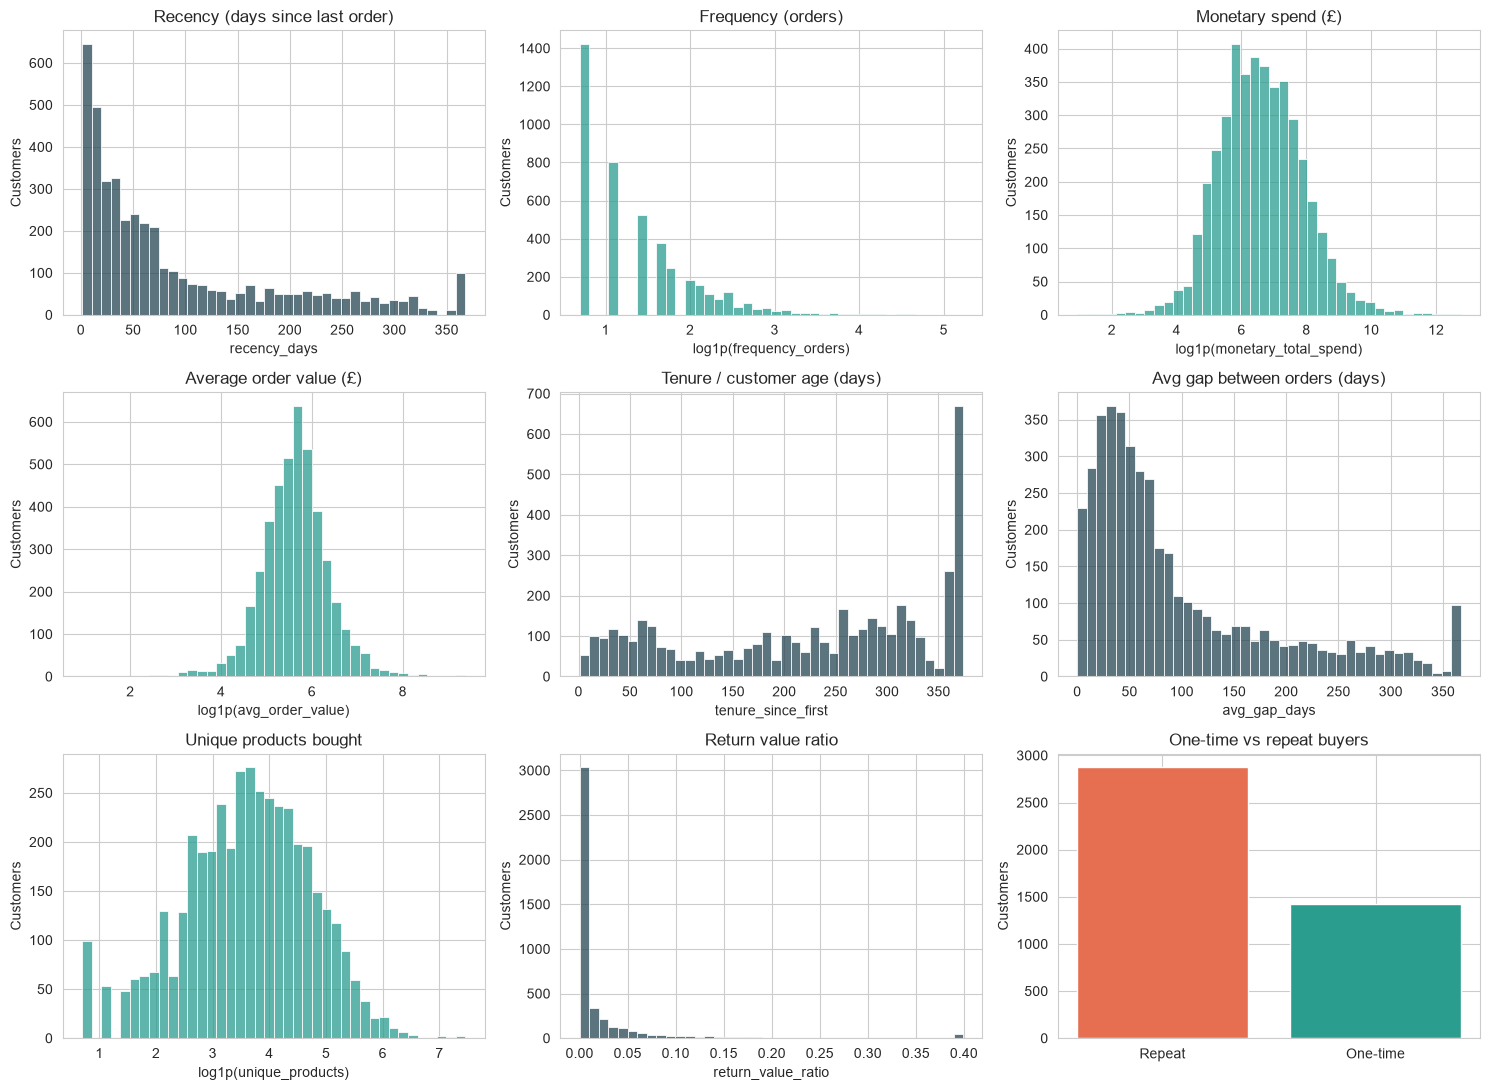

In [7]:
# A quick visual tour of the engineered features, grouped by what they capture.
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
panels = axes.ravel()

# (column, title, use log scale?)
plot_specs = [
    ('recency_days', 'Recency (days since last order)', False),
    ('frequency_orders', 'Frequency (orders)', True),
    ('monetary_total_spend', 'Monetary spend (£)', True),
    ('avg_order_value', 'Average order value (£)', True),
    ('tenure_since_first', 'Tenure / customer age (days)', False),
    ('avg_gap_days', 'Avg gap between orders (days)', False),
    ('unique_products', 'Unique products bought', True),
    ('return_value_ratio', 'Return value ratio', False),
]

for ax, (col, label, logx) in zip(panels, plot_specs):
    series = customer_features[col]
    if logx:
        sns.histplot(np.log1p(series), bins=40, color='#2a9d8f', ax=ax)
        ax.set_xlabel(f'log1p({col})')
    else:
        sns.histplot(series.clip(upper=series.quantile(0.99)), bins=40, color='#264653', ax=ax)
        ax.set_xlabel(col)
    ax.set_title(label)
    ax.set_ylabel('Customers')

# Final panel: one-time vs repeat buyers.
ax = panels[-1]
counts = (
    customer_features['is_one_time_buyer']
    .map({1: 'One-time', 0: 'Repeat'})
    .value_counts()
)
ax.bar(counts.index, counts.values, color=['#e76f51', '#2a9d8f'])
ax.set_title('One-time vs repeat buyers')
ax.set_ylabel('Customers')

plt.tight_layout()
plt.show()


## Feature health check & collinearity

Before handing this off to the modelling notebook, a quick look at distributions and correlations to spot redundant features. A lot of these are derived from the same base quantities (spend, order count), so some strong correlations are expected. The point is to see which ones we can safely drop or regularise.


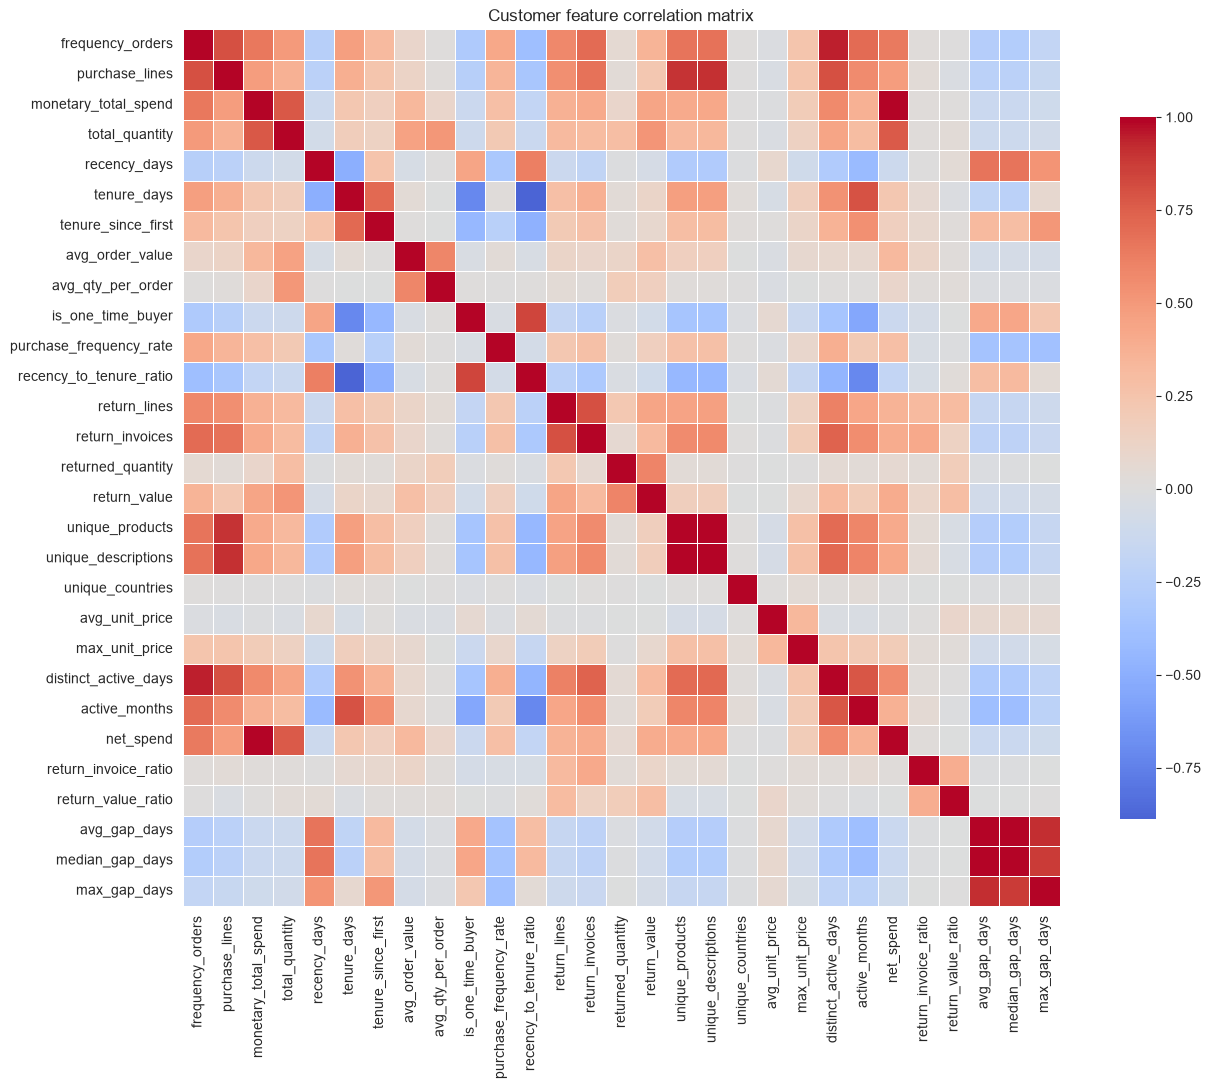

Top 10 most correlated feature pairs:


,feature_1,feature_2,correlation,abs_corr
481,unique_products,unique_descriptions,0.999,0.999
81,monetary_total_spend,net_spend,0.999,0.999
781,avg_gap_days,median_gap_days,0.994,0.994
21,frequency_orders,distinct_active_days,0.945,0.945
782,avg_gap_days,max_gap_days,0.915,0.915
46,purchase_lines,unique_descriptions,0.911,0.911
45,purchase_lines,unique_products,0.903,0.903
156,tenure_days,recency_to_tenure_ratio,-0.887,0.887
811,median_gap_days,max_gap_days,0.879,0.879
272,is_one_time_buyer,recency_to_tenure_ratio,0.843,0.843



Most right-skewed features (consider log-transform in NB4):


,skew
returned_quantity,61.36
avg_qty_per_order,45.73
unique_countries,29.27
avg_unit_price,26.89
net_spend,24.90
monetary_total_spend,24.32
return_value,20.55
total_quantity,20.27


In [8]:
# Correlation matrix of the numeric features
feature_cols = customer_features.select_dtypes(include=[np.number]).columns.tolist()
corr = customer_features[feature_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True,
            linewidths=0.4, cbar_kws={'shrink': 0.8})
plt.title('Customer feature correlation matrix')
plt.tight_layout()
plt.show()

# Pull out the strongest pairs (excluding self-pairs) as prune candidates for NB4
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feature_1', 'feature_2', 'correlation']
corr_pairs['abs_corr'] = corr_pairs['correlation'].abs()
print('Top 10 most correlated feature pairs:')
display(corr_pairs.sort_values('abs_corr', ascending=False).head(10).round(3))

# Most of the spend/order-count features are heavily right-skewed. Leave them raw here
# and handle the log/scaling in the modelling pipeline.
skew = customer_features[feature_cols].skew().sort_values(ascending=False)
print('\nMost right-skewed features (consider log-transform in NB4):')
display(skew.head(8).round(2).to_frame('skew'))


### What to prune in Notebook 4

The correlation scan turns up a handful of near-duplicate pairs that shouldn't all go into a linear model untransformed:

- `unique_products` vs `unique_descriptions` (r ~ 0.99): keep `unique_products`.
- `monetary_total_spend` vs `net_spend` (r ~ 0.99): keep one. Returns only claw back a small slice of revenue, and `net_spend` is the more honest number, so I'd keep that.
- `avg_gap_days` / `median_gap_days` / `max_gap_days` (r ~ 0.88-0.99): one gap feature is enough.
- `purchase_lines` vs `unique_products`, and `frequency_orders` vs `distinct_active_days`: both tightly coupled, so either pick one or let a tree model / regularisation sort it out.

Two more to leave out of the model matrix: `unique_countries` is basically constant, and `snapshot_date` is only there for lineage. And as the skew table shows, the monetary and quantity features are heavily right-skewed, so they'll want a log transform or robust scaling. That belongs in the Notebook 4 pipeline though, not here, so the scaler is fit on the training split only.


In [9]:
# Save features for downstream notebooks
out_file = BASE_DIR / 'customer_features.csv'
customer_features.to_csv(out_file, index=False)
print('Saved:', out_file.name)

Saved: customer_features.csv


## Feature data dictionary

Exporting a short description of every feature alongside the dataset, same as Notebook 1 did for the customer base.


In [10]:
# Feature data dictionary
feature_dictionary = pd.DataFrame([
    ('customer_id',             'string',   'Unique customer identifier'),
    ('last_purchase_date',      'datetime', 'Most recent purchase timestamp'),
    ('first_purchase_date',     'datetime', 'First purchase timestamp'),
    ('frequency_orders',        'int',      'RFM Frequency — distinct purchase invoices'),
    ('purchase_lines',          'int',      'Total purchase line items'),
    ('monetary_total_spend',    'float',    'RFM Monetary — gross purchase spend (£)'),
    ('total_quantity',          'int',      'Total units purchased'),
    ('recency_days',            'int',      'RFM Recency — days from last purchase to snapshot'),
    ('tenure_days',             'int',      'Active span: last_purchase − first_purchase (days)'),
    ('tenure_since_first',      'int',      'Customer age: snapshot − first_purchase (days)'),
    ('avg_order_value',         'float',    'monetary_total_spend / frequency_orders (£)'),
    ('avg_qty_per_order',       'float',    'total_quantity / frequency_orders'),
    ('is_one_time_buyer',       'int',      '1 if the customer placed exactly one order'),
    ('purchase_frequency_rate', 'float',    'frequency_orders / tenure_since_first (orders/day)'),
    ('recency_to_tenure_ratio', 'float',    'recency_days / tenure_since_first (0=just bought, 1=dormant)'),
    ('return_lines',            'int',      'Number of return / cancellation lines'),
    ('return_invoices',         'int',      'Number of distinct return / cancellation invoices'),
    ('returned_quantity',       'float',    'Total units returned'),
    ('return_value',            'float',    'Absolute value of returned line amounts (£)'),
    ('net_spend',               'float',    'monetary_total_spend − return_value (£)'),
    ('return_invoice_ratio',    'float',    'return_invoices / frequency_orders'),
    ('return_value_ratio',      'float',    'return_value / monetary_total_spend (uncapped)'),
    ('unique_products',         'int',      'Distinct stock codes purchased'),
    ('unique_descriptions',     'int',      'Distinct product descriptions purchased'),
    ('unique_countries',        'int',      'Distinct countries ordered from'),
    ('avg_unit_price',          'float',    'Mean unit price across purchase lines (£)'),
    ('max_unit_price',          'float',    'Maximum unit price paid (£)'),
    ('distinct_active_days',    'int',      'Distinct calendar days with a purchase'),
    ('active_months',           'int',      'Distinct calendar months with a purchase'),
    ('avg_gap_days',            'float',    'Mean days between purchases (imputed for one-time buyers)'),
    ('median_gap_days',         'float',    'Median inter-purchase gap (imputed for one-time buyers)'),
    ('max_gap_days',            'float',    'Max inter-purchase gap (imputed for one-time buyers)'),
    ('snapshot_date',           'datetime', 'Reference snapshot for recency / age features'),
], columns=['column', 'dtype', 'description'])

feature_dictionary.to_csv(BASE_DIR / 'customer_features_data_dictionary.csv', index=False)
display(feature_dictionary)
print('Saved: customer_features_data_dictionary.csv')


,column,dtype,description
0,customer_id,string,Unique customer identifier
1,last_purchase_date,datetime,Most recent purchase timestamp
2,first_purchase_date,datetime,First purchase timestamp
3,frequency_orders,int,RFM Frequency — distinct purchase invoices
4,purchase_lines,int,Total purchase line items
5,monetary_total_spend,float,RFM Monetary — gross purchase spend (£)
6,total_quantity,int,Total units purchased
7,recency_days,int,RFM Recency — days from last purchase to snapshot
8,tenure_days,int,Active span: last_purchase − first_purchase (d...
9,tenure_since_first,int,Customer age: snapshot − first_purchase (days)


Saved: customer_features_data_dictionary.csv


## Wrap-up

The output here is `customer_features.csv` (one row per customer) plus its data dictionary. The features fall into roughly six groups:

| Group | Features |
|-------|----------|
| RFM | `recency_days`, `frequency_orders`, `monetary_total_spend` |
| Value | `avg_order_value`, `net_spend`, `avg_qty_per_order`, `avg_unit_price`, `max_unit_price` |
| Tenure / age | `tenure_days`, `tenure_since_first` |
| Returns | `return_lines`, `return_invoices`, `return_value`, `return_invoice_ratio`, `return_value_ratio` |
| Engagement | `unique_products`, `distinct_active_days`, `active_months`, `is_one_time_buyer` |
| Velocity | `avg_gap_days`, `median_gap_days`, `max_gap_days`, `purchase_frequency_rate`, `recency_to_tenure_ratio` |

For modelling, keep one feature from each correlated cluster (see the prune notes above) and drop the constant/lineage columns. Save the log/scaling steps for the Notebook 4 pipeline.

One thing to remember: everything here is computed over the full history, so it's descriptive only. Notebook 3 deliberately rebuilds its features inside an earlier observation window before labelling churn, working off the same `clean_transactions.csv` from Notebook 1, so the model never sees anything from the future label window.
